In [1]:
import model3_free_text_chunked_pipeline_v3 as m3fc3

In [3]:
train_df, test_df = m3fc3.prepare_train_test_data(
    "free-text.csv",
    "synthetic_free_text.csv",
    "free-text_synthetic_realistic2.csv",
    chunk_size=50,
    test_size=0.2,
    random_state=42
)

Real raw shape: (562583, 9)
VAE raw shape: (562372, 9)
ChatGPT raw shape: (562583, 9)

Real train chunks shape: (8889, 19)
Real test chunks shape: (2264, 19)
VAE train chunks shape: (8886, 19)
VAE test chunks shape: (2263, 19)
ChatGPT train chunks shape: (8889, 19)
ChatGPT test chunks shape: (2264, 19)

Final train shape: (26664, 19)
Final test shape: (6791, 19)

Train class counts:
label
2    8889
0    8889
1    8886
Name: count, dtype: int64

Test class counts:
label
0    2264
2    2264
1    2263
Name: count, dtype: int64


In [4]:
X_train, X_test, y_train, y_test = m3fc3.preprocess_train_test(train_df, test_df)


Dropping columns: ['participant', 'session', 'chunk_id']

X_train shape: (26664, 15)
X_test shape: (6791, 15)


In [5]:
print(X_train.shape, X_test.shape)
print(y_train.value_counts())
print(y_test.value_counts())
print(X_train.columns)

(26664, 15) (6791, 15)
label
2    8889
0    8889
1    8886
Name: count, dtype: int64
label
0    2264
2    2264
1    2263
Name: count, dtype: int64
Index(['DU_hold_mean', 'DU_hold_std', 'DD_mean', 'DD_std', 'DU_flight_mean',
       'DU_flight_std', 'UD_mean', 'UD_std', 'UU_mean', 'UU_std',
       'total_events', 'total_time', 'avg_time_per_event', 'overall_mean',
       'overall_std'],
      dtype='object')


In [6]:
X_train_mi, X_test_mi, mi_features, mi_scores = m3fc3.select_mutual_info(
    X_train, y_train, X_test, k=10
)
X_train_mi_scaled, X_test_mi_scaled = m3fc3.scale_data(X_train_mi, X_test_mi)
mi_results = m3fc3.evaluate_models(X_train_mi_scaled, X_test_mi_scaled, y_train, y_test)


Top Mutual Information Features:
               Feature     Score
8              UU_mean  0.619974
4       DU_flight_mean  0.515031
5        DU_flight_std  0.501866
9               UU_std  0.489316
13        overall_mean  0.477717
11          total_time  0.475975
2              DD_mean  0.475502
12  avg_time_per_event  0.475376
3               DD_std  0.465036
6              UD_mean  0.459924

Model: Logistic Regression
Accuracy: 0.6781033721101458

Confusion Matrix:
[[ 976 1128  160]
 [ 889 1374    0]
 [   7    2 2255]]

Classification Report:
              precision    recall  f1-score   support

           0       0.52      0.43      0.47      2264
           1       0.55      0.61      0.58      2263
           2       0.93      1.00      0.96      2264

    accuracy                           0.68      6791
   macro avg       0.67      0.68      0.67      6791
weighted avg       0.67      0.68      0.67      6791


Model: Linear SVM
Accuracy: 0.66897364158445

Confusion Matrix:
[[

/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1281: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1296: FutureWarning: Using the 'liblinear' solver for multiclass classification is deprecated. An error will be raised in 1.8. Either use another solver which supports the multinomial loss or wrap the estimator in a OneVsRestClassifier to keep applying a one-versus-rest scheme.
  warnings.warn(


Accuracy: 0.9120895302606391

Confusion Matrix:
[[1690  551   23]
 [  14 2249    0]
 [   5    4 2255]]

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.75      0.85      2264
           1       0.80      0.99      0.89      2263
           2       0.99      1.00      0.99      2264

    accuracy                           0.91      6791
   macro avg       0.93      0.91      0.91      6791
weighted avg       0.93      0.91      0.91      6791


Model: Naive Bayes
Accuracy: 0.7013694595788543

Confusion Matrix:
[[ 800 1219  245]
 [ 397 1839   27]
 [ 135    5 2124]]

Classification Report:
              precision    recall  f1-score   support

           0       0.60      0.35      0.44      2264
           1       0.60      0.81      0.69      2263
           2       0.89      0.94      0.91      2264

    accuracy                           0.70      6791
   macro avg       0.70      0.70      0.68      6791
weighted avg       

In [7]:
X_train_anova, X_test_anova, anova_features, anova_scores = m3fc3.select_anova(
    X_train, y_train, X_test, k=10
)
X_train_anova_scaled, X_test_anova_scaled = m3fc3.scale_data(X_train_anova, X_test_anova)
anova_results = m3fc3.evaluate_models(X_train_anova_scaled, X_test_anova_scaled, y_train, y_test)

/opt/anaconda3/lib/python3.13/site-packages/sklearn/feature_selection/_univariate_selection.py:110: UserWarning: Features [10] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/opt/anaconda3/lib/python3.13/site-packages/sklearn/feature_selection/_univariate_selection.py:111: RuntimeWarning: invalid value encountered in divide
  f = msb / msw
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1281: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1296: FutureWarning: Using the 'liblinear' solver for multiclass classification is deprecated. An error will be raised in 1.8. Either use another solver which supports the multinomial loss or wrap the estimator in a OneVsRestClassifi


Top ANOVA Features:
               Feature         Score       P_Value
8              UU_mean  34690.597781  0.000000e+00
13        overall_mean  14457.829565  0.000000e+00
11          total_time   7529.110307  0.000000e+00
2              DD_mean   7529.110307  0.000000e+00
12  avg_time_per_event   7529.110307  0.000000e+00
4       DU_flight_mean   4867.249118  0.000000e+00
6              UD_mean   4252.033936  0.000000e+00
9               UU_std   1646.822434  0.000000e+00
14         overall_std   1238.225990  0.000000e+00
7               UD_std     28.871504  2.984172e-13

Model: Logistic Regression
Accuracy: 0.6700044176115447

Confusion Matrix:
[[1286  717  261]
 [1233 1027    3]
 [  12   15 2237]]

Classification Report:
              precision    recall  f1-score   support

           0       0.51      0.57      0.54      2264
           1       0.58      0.45      0.51      2263
           2       0.89      0.99      0.94      2264

    accuracy                           0.67  

In [8]:
X_train_corr, X_test_corr, corr_features, corr_scores = m3fc3.select_correlation(
    X_train, y_train, X_test, k=10
)
X_train_corr_scaled, X_test_corr_scaled = m3fc3.scale_data(X_train_corr, X_test_corr)
corr_results = m3fc3.evaluate_models(X_train_corr_scaled, X_test_corr_scaled, y_train, y_test)


Top Correlation Features:
              Feature     Score
0             UU_mean  0.733083
1        overall_mean  0.620448
2             DD_mean  0.529114
3          total_time  0.529114
4  avg_time_per_event  0.529114
5             UD_mean  0.438398
6      DU_flight_mean  0.437865
7              UU_std  0.292465
8         overall_std  0.264896
9              UD_std  0.039483

Model: Logistic Regression
Accuracy: 0.6700044176115447

Confusion Matrix:
[[1286  717  261]
 [1233 1027    3]
 [  12   15 2237]]

Classification Report:
              precision    recall  f1-score   support

           0       0.51      0.57      0.54      2264
           1       0.58      0.45      0.51      2263
           2       0.89      0.99      0.94      2264

    accuracy                           0.67      6791
   macro avg       0.66      0.67      0.66      6791
weighted avg       0.66      0.67      0.66      6791


Model: Linear SVM
Accuracy: 0.670887939920483

Confusion Matrix:
[[1273  678  313]
 

/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1281: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1296: FutureWarning: Using the 'liblinear' solver for multiclass classification is deprecated. An error will be raised in 1.8. Either use another solver which supports the multinomial loss or wrap the estimator in a OneVsRestClassifier to keep applying a one-versus-rest scheme.
  warnings.warn(


Accuracy: 0.9384479458106317

Confusion Matrix:
[[2009  231   24]
 [ 150 2110    3]
 [   4    6 2254]]

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.89      0.91      2264
           1       0.90      0.93      0.92      2263
           2       0.99      1.00      0.99      2264

    accuracy                           0.94      6791
   macro avg       0.94      0.94      0.94      6791
weighted avg       0.94      0.94      0.94      6791


Model: Naive Bayes
Accuracy: 0.6948902959799735

Confusion Matrix:
[[ 733 1294  237]
 [ 386 1852   25]
 [ 123    7 2134]]

Classification Report:
              precision    recall  f1-score   support

           0       0.59      0.32      0.42      2264
           1       0.59      0.82      0.68      2263
           2       0.89      0.94      0.92      2264

    accuracy                           0.69      6791
   macro avg       0.69      0.69      0.67      6791
weighted avg       

In [9]:
X_train_var, X_test_var, var_features, var_scores = m3fc3.select_variance(
    X_train, X_test, threshold=0.0, k=10
)
X_train_var_scaled, X_test_var_scaled = m3fc3.scale_data(X_train_var, X_test_var)
var_results = m3fc3.evaluate_models(X_train_var_scaled, X_test_var_scaled, y_train, y_test)


Top Variance Features:
              Feature       Score
0          total_time  131.808716
1              DD_std    3.082323
2         DU_hold_std    1.950820
3       DU_flight_std    1.735738
4              UD_std    1.476486
5      DU_flight_mean    0.073784
6        DU_hold_mean    0.057767
7             DD_mean    0.052723
8  avg_time_per_event    0.052723
9             UD_mean    0.051042

Model: Logistic Regression
Accuracy: 0.6814902076277426

Confusion Matrix:
[[ 976 1064  224]
 [ 833 1420   10]
 [  12   20 2232]]

Classification Report:
              precision    recall  f1-score   support

           0       0.54      0.43      0.48      2264
           1       0.57      0.63      0.60      2263
           2       0.91      0.99      0.94      2264

    accuracy                           0.68      6791
   macro avg       0.67      0.68      0.67      6791
weighted avg       0.67      0.68      0.67      6791


Model: Linear SVM
Accuracy: 0.6769253423648948

Confusion Matrix:

/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1281: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1296: FutureWarning: Using the 'liblinear' solver for multiclass classification is deprecated. An error will be raised in 1.8. Either use another solver which supports the multinomial loss or wrap the estimator in a OneVsRestClassifier to keep applying a one-versus-rest scheme.
  warnings.warn(


Accuracy: 0.8985421881902518

Confusion Matrix:
[[1660  560   44]
 [  65 2194    4]
 [   4   12 2248]]

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.73      0.83      2264
           1       0.79      0.97      0.87      2263
           2       0.98      0.99      0.99      2264

    accuracy                           0.90      6791
   macro avg       0.91      0.90      0.90      6791
weighted avg       0.91      0.90      0.90      6791


Model: Naive Bayes
Accuracy: 0.5809159181269327

Confusion Matrix:
[[ 214 1891  159]
 [ 415 1662  186]
 [ 108   87 2069]]

Classification Report:
              precision    recall  f1-score   support

           0       0.29      0.09      0.14      2264
           1       0.46      0.73      0.56      2263
           2       0.86      0.91      0.88      2264

    accuracy                           0.58      6791
   macro avg       0.53      0.58      0.53      6791
weighted avg       

In [10]:
X_train_md, X_test_md, md_features, md_scores = m3fc3.select_mean_difference(
    X_train, y_train, X_test, k=10
)
X_train_md_scaled, X_test_md_scaled = m3fc3.scale_data(X_train_md, X_test_md)
md_results = m3fc3.evaluate_models(X_train_md_scaled, X_test_md_scaled, y_train, y_test)


Top Mean Difference Features:
              Feature      Score
0          total_time  14.878677
1      DU_flight_mean   0.304244
2             DD_mean   0.297574
3  avg_time_per_event   0.297573
4             UU_mean   0.250452
5             UD_mean   0.242591
6        overall_mean   0.223270
7              UU_std   0.149232
8              UD_std   0.122013
9         overall_std   0.117987

Model: Logistic Regression
Accuracy: 0.6700044176115447

Confusion Matrix:
[[1286  717  261]
 [1233 1027    3]
 [  12   15 2237]]

Classification Report:
              precision    recall  f1-score   support

           0       0.51      0.57      0.54      2264
           1       0.58      0.45      0.51      2263
           2       0.89      0.99      0.94      2264

    accuracy                           0.67      6791
   macro avg       0.66      0.67      0.66      6791
weighted avg       0.66      0.67      0.66      6791


Model: Linear SVM
Accuracy: 0.670887939920483

Confusion Matrix:
[[12

/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1281: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1296: FutureWarning: Using the 'liblinear' solver for multiclass classification is deprecated. An error will be raised in 1.8. Either use another solver which supports the multinomial loss or wrap the estimator in a OneVsRestClassifier to keep applying a one-versus-rest scheme.
  warnings.warn(


Accuracy: 0.9380061846561626

Confusion Matrix:
[[2003  233   28]
 [ 150 2112    1]
 [   4    5 2255]]

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.88      0.91      2264
           1       0.90      0.93      0.92      2263
           2       0.99      1.00      0.99      2264

    accuracy                           0.94      6791
   macro avg       0.94      0.94      0.94      6791
weighted avg       0.94      0.94      0.94      6791


Model: Naive Bayes
Accuracy: 0.6948902959799735

Confusion Matrix:
[[ 733 1294  237]
 [ 386 1852   25]
 [ 123    7 2134]]

Classification Report:
              precision    recall  f1-score   support

           0       0.59      0.32      0.42      2264
           1       0.59      0.82      0.68      2263
           2       0.89      0.94      0.92      2264

    accuracy                           0.69      6791
   macro avg       0.69      0.69      0.67      6791
weighted avg       

In [11]:
X_train_rfe_lr, X_test_rfe_lr, rfe_lr_features = m3fc3.select_rfe_lr(
    X_train, y_train, X_test, k=10
)
X_train_rfe_lr_scaled, X_test_rfe_lr_scaled = m3fc3.scale_data(X_train_rfe_lr, X_test_rfe_lr)
rfe_lr_results = m3fc3.evaluate_models(X_train_rfe_lr_scaled, X_test_rfe_lr_scaled, y_train, y_test)

/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1281: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1296: FutureWarning: Using the 'liblinear' solver for multiclass classification is deprecated. An error will be raised in 1.8. Either use another solver which supports the multinomial loss or wrap the estimator in a OneVsRestClassifier to keep applying a one-versus-rest scheme.
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1281: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
/opt/anaconda3/lib/python3.13/


RFE Logistic Regression Features:
['DU_hold_mean', 'DU_hold_std', 'DU_flight_mean', 'DU_flight_std', 'UD_mean', 'UD_std', 'UU_mean', 'UU_std', 'overall_mean', 'overall_std']

Model: Logistic Regression
Accuracy: 0.6931232513620968

Confusion Matrix:
[[1282  843  139]
 [1094 1169    0]
 [   1    7 2256]]

Classification Report:
              precision    recall  f1-score   support

           0       0.54      0.57      0.55      2264
           1       0.58      0.52      0.55      2263
           2       0.94      1.00      0.97      2264

    accuracy                           0.69      6791
   macro avg       0.69      0.69      0.69      6791
weighted avg       0.69      0.69      0.69      6791


Model: Linear SVM
Accuracy: 0.6926814902076277

Confusion Matrix:
[[1271  829  164]
 [1086 1177    0]
 [   1    7 2256]]

Classification Report:
              precision    recall  f1-score   support

           0       0.54      0.56      0.55      2264
           1       0.58      0.52 

/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1281: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1296: FutureWarning: Using the 'liblinear' solver for multiclass classification is deprecated. An error will be raised in 1.8. Either use another solver which supports the multinomial loss or wrap the estimator in a OneVsRestClassifier to keep applying a one-versus-rest scheme.
  warnings.warn(


Accuracy: 0.8976586658813135

Confusion Matrix:
[[1648  594   22]
 [  71 2190    2]
 [   3    3 2258]]

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.73      0.83      2264
           1       0.79      0.97      0.87      2263
           2       0.99      1.00      0.99      2264

    accuracy                           0.90      6791
   macro avg       0.91      0.90      0.90      6791
weighted avg       0.91      0.90      0.90      6791


Model: Naive Bayes
Accuracy: 0.6315711971727286

Confusion Matrix:
[[ 339 1707  218]
 [ 453 1806    4]
 [ 115    5 2144]]

Classification Report:
              precision    recall  f1-score   support

           0       0.37      0.15      0.21      2264
           1       0.51      0.80      0.62      2263
           2       0.91      0.95      0.93      2264

    accuracy                           0.63      6791
   macro avg       0.60      0.63      0.59      6791
weighted avg       

In [12]:
X_train_rfe_svm, X_test_rfe_svm, rfe_svm_features = m3fc3.select_rfe_svm(
    X_train, y_train, X_test, k=10
)
X_train_rfe_svm_scaled, X_test_rfe_svm_scaled = m3fc3.scale_data(X_train_rfe_svm, X_test_rfe_svm)
rfe_svm_results = m3fc3.evaluate_models(X_train_rfe_svm_scaled, X_test_rfe_svm_scaled, y_train, y_test)


RFE Linear SVM Features:
['DU_hold_mean', 'DU_hold_std', 'DU_flight_mean', 'DU_flight_std', 'UD_mean', 'UD_std', 'UU_mean', 'UU_std', 'overall_mean', 'overall_std']

Model: Logistic Regression
Accuracy: 0.6931232513620968

Confusion Matrix:
[[1282  843  139]
 [1094 1169    0]
 [   1    7 2256]]

Classification Report:
              precision    recall  f1-score   support

           0       0.54      0.57      0.55      2264
           1       0.58      0.52      0.55      2263
           2       0.94      1.00      0.97      2264

    accuracy                           0.69      6791
   macro avg       0.69      0.69      0.69      6791
weighted avg       0.69      0.69      0.69      6791


Model: Linear SVM
Accuracy: 0.6926814902076277

Confusion Matrix:
[[1271  829  164]
 [1086 1177    0]
 [   1    7 2256]]

Classification Report:
              precision    recall  f1-score   support

           0       0.54      0.56      0.55      2264
           1       0.58      0.52      0.55

/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1281: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1296: FutureWarning: Using the 'liblinear' solver for multiclass classification is deprecated. An error will be raised in 1.8. Either use another solver which supports the multinomial loss or wrap the estimator in a OneVsRestClassifier to keep applying a one-versus-rest scheme.
  warnings.warn(


Accuracy: 0.8976586658813135

Confusion Matrix:
[[1648  594   22]
 [  71 2190    2]
 [   3    3 2258]]

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.73      0.83      2264
           1       0.79      0.97      0.87      2263
           2       0.99      1.00      0.99      2264

    accuracy                           0.90      6791
   macro avg       0.91      0.90      0.90      6791
weighted avg       0.91      0.90      0.90      6791


Model: Naive Bayes
Accuracy: 0.6315711971727286

Confusion Matrix:
[[ 339 1707  218]
 [ 453 1806    4]
 [ 115    5 2144]]

Classification Report:
              precision    recall  f1-score   support

           0       0.37      0.15      0.21      2264
           1       0.51      0.80      0.62      2263
           2       0.91      0.95      0.93      2264

    accuracy                           0.63      6791
   macro avg       0.60      0.63      0.59      6791
weighted avg       

In [13]:
X_train_rfe_rf, X_test_rfe_rf, rfe_rf_features = m3fc3.select_rfe_rf(
    X_train, y_train, X_test, k=10
)
X_train_rfe_rf_scaled, X_test_rfe_rf_scaled = m3fc3.scale_data(X_train_rfe_rf, X_test_rfe_rf)
rfe_rf_results = m3fc3.evaluate_models(X_train_rfe_rf_scaled, X_test_rfe_rf_scaled, y_train, y_test)


RFE Random Forest Features:
['DU_hold_std', 'DD_std', 'DU_flight_mean', 'DU_flight_std', 'UD_mean', 'UU_mean', 'UU_std', 'total_time', 'avg_time_per_event', 'overall_mean']

Model: Logistic Regression
Accuracy: 0.6688263878662937

Confusion Matrix:
[[ 957 1148  159]
 [ 931 1332    0]
 [  10    1 2253]]

Classification Report:
              precision    recall  f1-score   support

           0       0.50      0.42      0.46      2264
           1       0.54      0.59      0.56      2263
           2       0.93      1.00      0.96      2264

    accuracy                           0.67      6791
   macro avg       0.66      0.67      0.66      6791
weighted avg       0.66      0.67      0.66      6791


Model: Linear SVM
Accuracy: 0.6655868060668532

Confusion Matrix:
[[ 861 1219  184]
 [ 859 1404    0]
 [   8    1 2255]]

Classification Report:
              precision    recall  f1-score   support

           0       0.50      0.38      0.43      2264
           1       0.54      0.62  

/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1281: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1296: FutureWarning: Using the 'liblinear' solver for multiclass classification is deprecated. An error will be raised in 1.8. Either use another solver which supports the multinomial loss or wrap the estimator in a OneVsRestClassifier to keep applying a one-versus-rest scheme.
  warnings.warn(


Accuracy: 0.8767486379031071

Confusion Matrix:
[[1496  741   27]
 [  63 2200    0]
 [   4    2 2258]]

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.66      0.78      2264
           1       0.75      0.97      0.85      2263
           2       0.99      1.00      0.99      2264

    accuracy                           0.88      6791
   macro avg       0.90      0.88      0.87      6791
weighted avg       0.90      0.88      0.87      6791


Model: Naive Bayes
Accuracy: 0.6738330142836106

Confusion Matrix:
[[ 640 1396  228]
 [ 435 1807   21]
 [ 132    3 2129]]

Classification Report:
              precision    recall  f1-score   support

           0       0.53      0.28      0.37      2264
           1       0.56      0.80      0.66      2263
           2       0.90      0.94      0.92      2264

    accuracy                           0.67      6791
   macro avg       0.66      0.67      0.65      6791
weighted avg       

In [14]:
X_train_sfm_lr, X_test_sfm_lr, sfm_lr_features, sfm_lr_scores = m3fc3.select_sfm_lr(
    X_train, y_train, X_test, k=10
)
X_train_sfm_lr_scaled, X_test_sfm_lr_scaled = m3fc3.scale_data(X_train_sfm_lr, X_test_sfm_lr)
sfm_lr_results = m3fc3.evaluate_models(X_train_sfm_lr_scaled, X_test_sfm_lr_scaled, y_train, y_test)

/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1281: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1296: FutureWarning: Using the 'liblinear' solver for multiclass classification is deprecated. An error will be raised in 1.8. Either use another solver which supports the multinomial loss or wrap the estimator in a OneVsRestClassifier to keep applying a one-versus-rest scheme.
  warnings.warn(



SelectFromModel Logistic Regression Features:
           Feature      Score
8          UU_mean  14.188592
14     overall_std  10.449682
4   DU_flight_mean   7.885735
0     DU_hold_mean   6.564804
9           UU_std   4.086962
13    overall_mean   2.864798
6          UD_mean   2.345201
5    DU_flight_std   1.773895
1      DU_hold_std   1.176241
7           UD_std   0.397019

Model: Logistic Regression
Accuracy: 0.6931232513620968

Confusion Matrix:
[[1282  843  139]
 [1094 1169    0]
 [   1    7 2256]]

Classification Report:
              precision    recall  f1-score   support

           0       0.54      0.57      0.55      2264
           1       0.58      0.52      0.55      2263
           2       0.94      1.00      0.97      2264

    accuracy                           0.69      6791
   macro avg       0.69      0.69      0.69      6791
weighted avg       0.69      0.69      0.69      6791


Model: Linear SVM
Accuracy: 0.6926814902076277

Confusion Matrix:
[[1271  829  164]
 [

/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1281: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1296: FutureWarning: Using the 'liblinear' solver for multiclass classification is deprecated. An error will be raised in 1.8. Either use another solver which supports the multinomial loss or wrap the estimator in a OneVsRestClassifier to keep applying a one-versus-rest scheme.
  warnings.warn(


Accuracy: 0.8979531733176263

Confusion Matrix:
[[1647  599   18]
 [  70 2192    1]
 [   3    2 2259]]

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.73      0.83      2264
           1       0.78      0.97      0.87      2263
           2       0.99      1.00      0.99      2264

    accuracy                           0.90      6791
   macro avg       0.91      0.90      0.90      6791
weighted avg       0.91      0.90      0.90      6791


Model: Naive Bayes
Accuracy: 0.6315711971727286

Confusion Matrix:
[[ 339 1707  218]
 [ 453 1806    4]
 [ 115    5 2144]]

Classification Report:
              precision    recall  f1-score   support

           0       0.37      0.15      0.21      2264
           1       0.51      0.80      0.62      2263
           2       0.91      0.95      0.93      2264

    accuracy                           0.63      6791
   macro avg       0.60      0.63      0.59      6791
weighted avg       

In [15]:
X_train_sfm_rf, X_test_sfm_rf, sfm_rf_features, sfm_rf_scores = m3fc3.select_sfm_rf(
    X_train, y_train, X_test, k=10
)
X_train_sfm_rf_scaled, X_test_sfm_rf_scaled = m3fc3.scale_data(X_train_sfm_rf, X_test_sfm_rf)
sfm_rf_results = m3fc3.evaluate_models(X_train_sfm_rf_scaled, X_test_sfm_rf_scaled, y_train, y_test)



SelectFromModel Random Forest Features:
           Feature     Score
8          UU_mean  0.220780
13    overall_mean  0.135717
4   DU_flight_mean  0.119808
6          UD_mean  0.101187
1      DU_hold_std  0.064104
9           UU_std  0.057606
14     overall_std  0.051948
0     DU_hold_mean  0.042612
3           DD_std  0.041617
5    DU_flight_std  0.041337

Model: Logistic Regression
Accuracy: 0.6857605654542778

Confusion Matrix:
[[1210  911  143]
 [1073 1189    1]
 [   0    6 2258]]

Classification Report:
              precision    recall  f1-score   support

           0       0.53      0.53      0.53      2264
           1       0.56      0.53      0.54      2263
           2       0.94      1.00      0.97      2264

    accuracy                           0.69      6791
   macro avg       0.68      0.69      0.68      6791
weighted avg       0.68      0.69      0.68      6791


Model: Linear SVM
Accuracy: 0.6814902076277426

Confusion Matrix:
[[1199  903  162]
 [1091 1171    1]
 

/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1281: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1296: FutureWarning: Using the 'liblinear' solver for multiclass classification is deprecated. An error will be raised in 1.8. Either use another solver which supports the multinomial loss or wrap the estimator in a OneVsRestClassifier to keep applying a one-versus-rest scheme.
  warnings.warn(


Accuracy: 0.9007509939625975

Confusion Matrix:
[[1663  567   34]
 [  65 2197    1]
 [   4    3 2257]]

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.73      0.83      2264
           1       0.79      0.97      0.87      2263
           2       0.98      1.00      0.99      2264

    accuracy                           0.90      6791
   macro avg       0.91      0.90      0.90      6791
weighted avg       0.91      0.90      0.90      6791


Model: Naive Bayes
Accuracy: 0.6387866293623914

Confusion Matrix:
[[ 353 1690  221]
 [ 407 1853    3]
 [ 128    4 2132]]

Classification Report:
              precision    recall  f1-score   support

           0       0.40      0.16      0.22      2264
           1       0.52      0.82      0.64      2263
           2       0.90      0.94      0.92      2264

    accuracy                           0.64      6791
   macro avg       0.61      0.64      0.59      6791
weighted avg       

In [16]:
print("MI best:\n", mi_results.iloc[0][["Model", "Accuracy"]])
print("\nANOVA best:\n", anova_results.iloc[0][["Model", "Accuracy"]])
print("\nCorrelation best:\n", corr_results.iloc[0][["Model", "Accuracy"]])
print("\nVariance best:\n", var_results.iloc[0][["Model", "Accuracy"]])
print("\nMean Difference best:\n", md_results.iloc[0][["Model", "Accuracy"]])
print("\nRFE LR best:\n", rfe_lr_results.iloc[0][["Model", "Accuracy"]])
print("\nRFE SVM best:\n", rfe_svm_results.iloc[0][["Model", "Accuracy"]])
print("\nRFE RF best:\n", rfe_rf_results.iloc[0][["Model", "Accuracy"]])
print("\nSFM LR best:\n", sfm_lr_results.iloc[0][["Model", "Accuracy"]])
print("\nSFM RF best:\n", sfm_rf_results.iloc[0][["Model", "Accuracy"]])

MI best:
 Model       Random Forest
Accuracy          0.91209
Name: 2, dtype: object

ANOVA best:
 Model       Random Forest
Accuracy          0.94154
Name: 2, dtype: object

Correlation best:
 Model       Random Forest
Accuracy         0.938448
Name: 2, dtype: object

Variance best:
 Model       Random Forest
Accuracy         0.898542
Name: 2, dtype: object

Mean Difference best:
 Model       Random Forest
Accuracy         0.938006
Name: 2, dtype: object

RFE LR best:
 Model       Random Forest
Accuracy         0.897659
Name: 2, dtype: object

RFE SVM best:
 Model       Random Forest
Accuracy         0.897659
Name: 2, dtype: object

RFE RF best:
 Model       Random Forest
Accuracy         0.876749
Name: 2, dtype: object

SFM LR best:
 Model       Random Forest
Accuracy         0.897953
Name: 2, dtype: object

SFM RF best:
 Model       Random Forest
Accuracy         0.900751
Name: 2, dtype: object


In [17]:
summary_df = m3fc3.feature_selection_summary(
    mi_features,
    anova_features,
    corr_features,
    var_features,
    md_features,
    rfe_lr_features,
    rfe_svm_features,
    rfe_rf_features,
    sfm_lr_features,
    sfm_rf_features
)

summary_df.head(15)


Feature Selection Summary:
               Feature  Times_Selected
1       DU_flight_mean              10
9              UD_mean              10
0              UU_mean               9
3               UU_std               9
4         overall_mean               9
2        DU_flight_std               7
10         overall_std               7
11              UD_std               7
5           total_time               6
7   avg_time_per_event               6
12         DU_hold_std               6
6              DD_mean               5
13        DU_hold_mean               5
8               DD_std               4


,Feature,Times_Selected
1,DU_flight_mean,10
9,UD_mean,10
0,UU_mean,9
3,UU_std,9
4,overall_mean,9
2,DU_flight_std,7
10,overall_std,7
11,UD_std,7
5,total_time,6
7,avg_time_per_event,6


In [18]:
best_model = m3fc3.get_models()["Random Forest"]

X_train_best, X_test_best, selected_features, score_df = m3fc3.select_anova(
    X_train, y_train, X_test, k=10
)

X_train_best_scaled, X_test_best_scaled = m3fc3.scale_data(
    X_train_best, X_test_best
)

best_model.fit(X_train_best_scaled, y_train)

y_pred_best = best_model.predict(X_test_best_scaled)

from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred_best)

print("Best Method: ANOVA + Random Forest")
print("Selected Features:", selected_features)
print("Accuracy:", (y_pred_best == y_test).mean())
print("Confusion Matrix:\n", cm)

/opt/anaconda3/lib/python3.13/site-packages/sklearn/feature_selection/_univariate_selection.py:110: UserWarning: Features [10] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/opt/anaconda3/lib/python3.13/site-packages/sklearn/feature_selection/_univariate_selection.py:111: RuntimeWarning: invalid value encountered in divide
  f = msb / msw



Top ANOVA Features:
               Feature         Score       P_Value
8              UU_mean  34690.597781  0.000000e+00
13        overall_mean  14457.829565  0.000000e+00
11          total_time   7529.110307  0.000000e+00
2              DD_mean   7529.110307  0.000000e+00
12  avg_time_per_event   7529.110307  0.000000e+00
4       DU_flight_mean   4867.249118  0.000000e+00
6              UD_mean   4252.033936  0.000000e+00
9               UU_std   1646.822434  0.000000e+00
14         overall_std   1238.225990  0.000000e+00
7               UD_std     28.871504  2.984172e-13
Best Method: ANOVA + Random Forest
Selected Features: ['UU_mean', 'overall_mean', 'total_time', 'DD_mean', 'avg_time_per_event', 'DU_flight_mean', 'UD_mean', 'UU_std', 'overall_std', 'UD_std']
Accuracy: 0.9415402738919157
Confusion Matrix:
 [[2065  169   30]
 [ 187 2074    2]
 [   2    7 2255]]


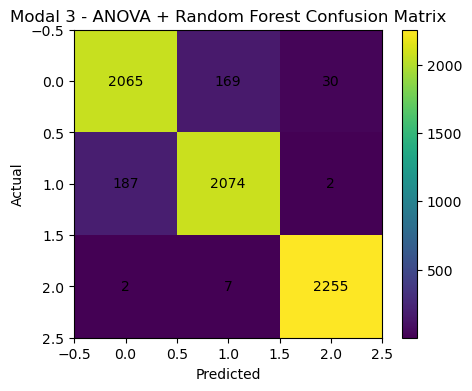

In [19]:
m3fc3.plot_confusion_matrix(cm, title="Modal 3 - ANOVA + Random Forest Confusion Matrix")

In [20]:
cv_scores = m3fc3.validate_best_model(
    best_model,
    X_train_best_scaled,
    y_train
)

cv_scores


3-Fold CV Scores: [0.94250675 0.91347885 0.93564356]
CV Mean: 0.9305430543054305


array([0.94250675, 0.91347885, 0.93564356])


Feature: UU_mean
Real Mean: 0.292293171344033
VAE Mean: 0.25434664802762674
ChatGPT Mean: 0.5155087129456882


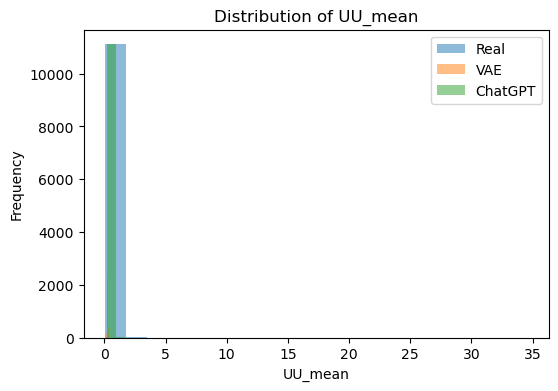


Feature: overall_mean
Real Mean: 0.2744690121043665
VAE Mean: 0.2418970382721353
ChatGPT Mean: 0.4744857969068607


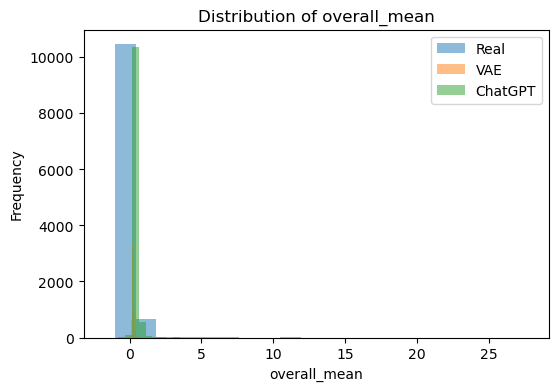

In [21]:
m3fc3.plot_feature_distribution_from_train_test(
    train_df,
    test_df,
    "UU_mean"
)

m3fc3.plot_feature_distribution_from_train_test(
    train_df,
    test_df,
    "overall_mean"
)